# Integration of peak area and heatmap plotting

In most cases, a quick way to analyse the Raman/PL mapping data is to integrate the area under the peak of interest, and plot the integrated intensity as a heatmap. This section demonstrates how to do this using the `RamanPL_2D` package.

## Raman Peak Area Integration

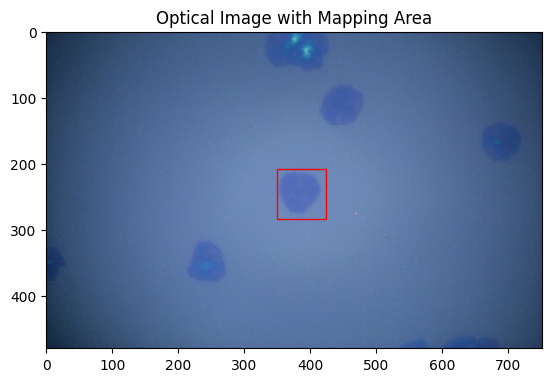

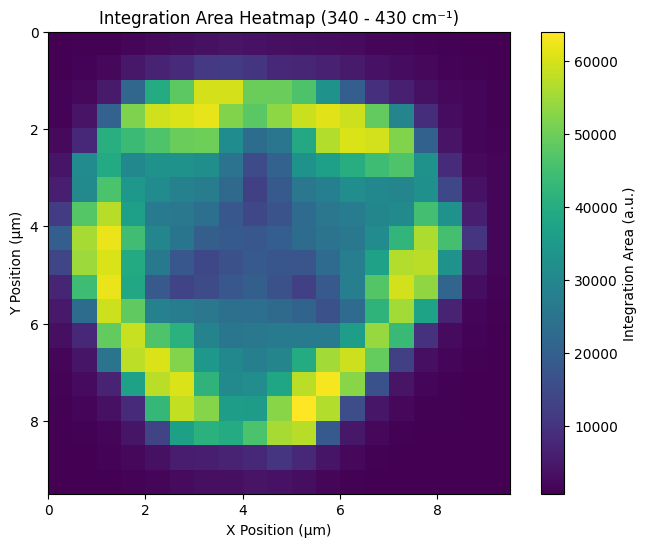

In [1]:
from ramanpl import Mapping

# Define integration parameters
integration_range = (340, 430)  # Range of intergrated spectrum range, unit cm-1
step_size = 0.5  # Check your actual step-size

# Initialise the class module
raman_integration = Mapping.Raman_Integration('Mapping Raman Sample.wdf', 
                                      integration_range=integration_range, 
                                      step_size=step_size, 
                                      background_remove=False,
                                      poly_degree=2)

# Display optcial image (optional)
raman_integration.show_optical_image()

# Calculate integrated area
raman_integration.calculate_integration()

# Plot heatmap of integration
raman_integration.plot_integration_heatmap()

You can also check the point spectrum at a specific location, e.g. at (x=5, y=65): 

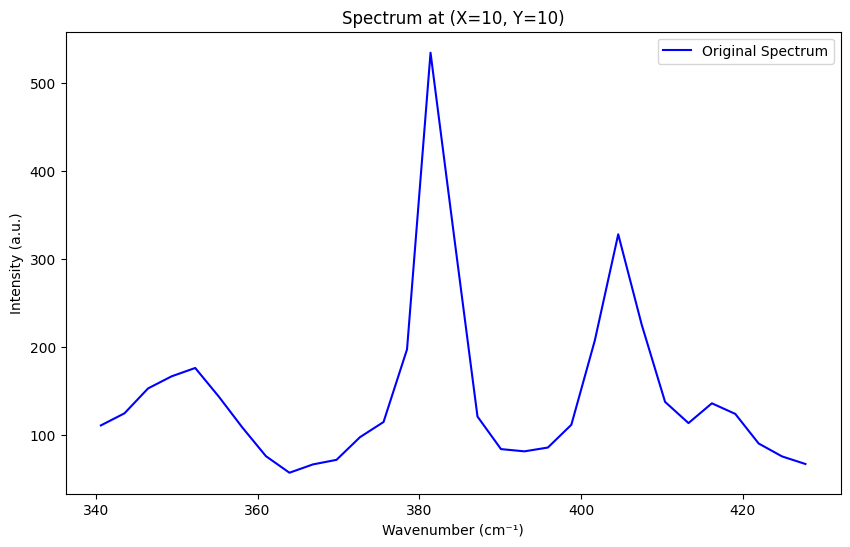

In [2]:
# Check spectrum background removal
raman_integration.plot_spectrum(x=10, y=10)

### Export integration map to file
You can export the integrated intensity maps to text or CSV files using the `export_integration_map` method. By default, the exported TXT file includes a metadata header. You can suppress this header by setting the `headers` parameter to `False`. The exported data files can be used elsewhere for further analysis or visualization.

```python
raman_integration.export_integration_map("outputs/raman_integration_map.txt", coord_mode="real")
```

In [3]:
raman_integration.export_integration_map("outputs/raman_example_integration_map.txt", coord_mode="real")

'outputs/raman_example_integration_map.txt'

### Raman interation mapping after subtraction of external file
You can also do that for Raman integration results with the in-memory data cube `cubeC`:

```python

from ramanpl import Mapping

raman_int = Mapping.Raman_Integration.from_arrays(
    spectra=cubeC,
    xdata=xC,
    X=X,
    Y=Y,
    integration_range=(150, 900),
    step_size=1.0,
    background_remove=True,
    baseline_method="poly",
)

raman_int.integrate()
raman_int.plot_integration_map()

```

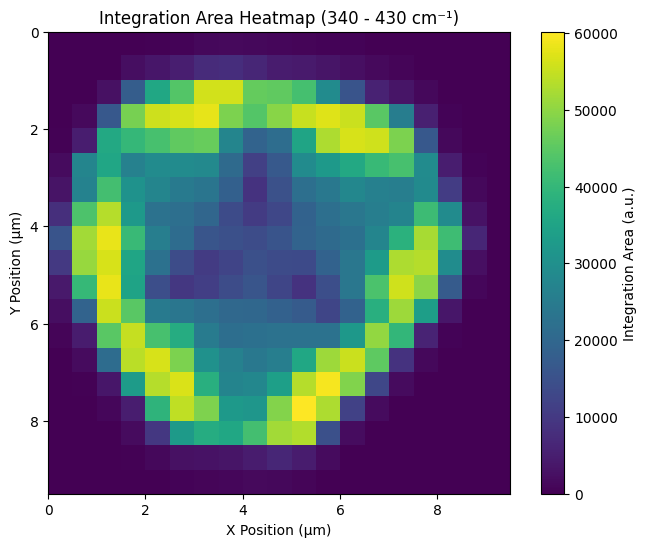

In [4]:
from ramanpl import Mapping
from ramanpl.operation import ArithmeticSpectrum

cubeC, xC, X, Y = ArithmeticSpectrum.combine_map_with_reference(
    "Mapping Raman Sample.wdf",        # mapping data file
    "Raman_Si_ref.txt",                # single reference spectrum
    op="sub",
    k=1,
    axis="wavenumber",
    align="interp",
    save=True,
    out_path="Raman_map_subtracted.txt",
    clip_nonnegative=True               # Ensure no negative values after subtraction
)

raman_int = Mapping.Raman_Integration.from_arrays(
    spectra=cubeC,
    xdata=xC,
    X=X,
    Y=Y,
    integration_range=(340, 430),
    step_size=0.5,
    background_remove=False,
)

# Calculate integrated area
raman_int.calculate_integration()

# Plot heatmap of integration
raman_int.plot_integration_heatmap()


----

## PL Peak Area Integration

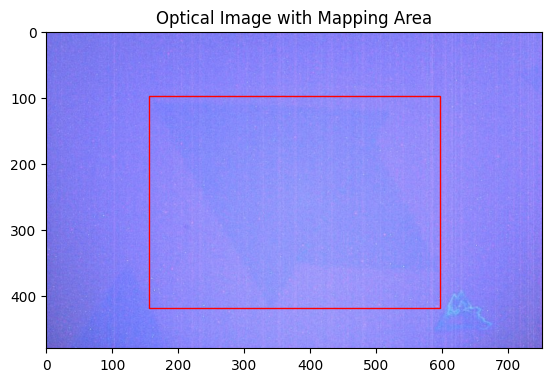

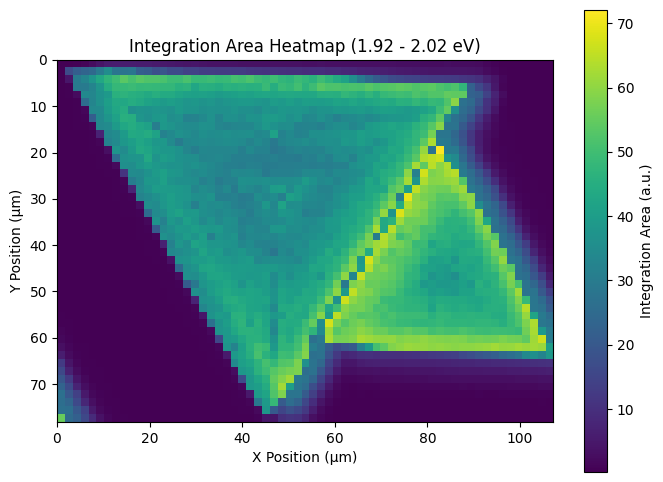

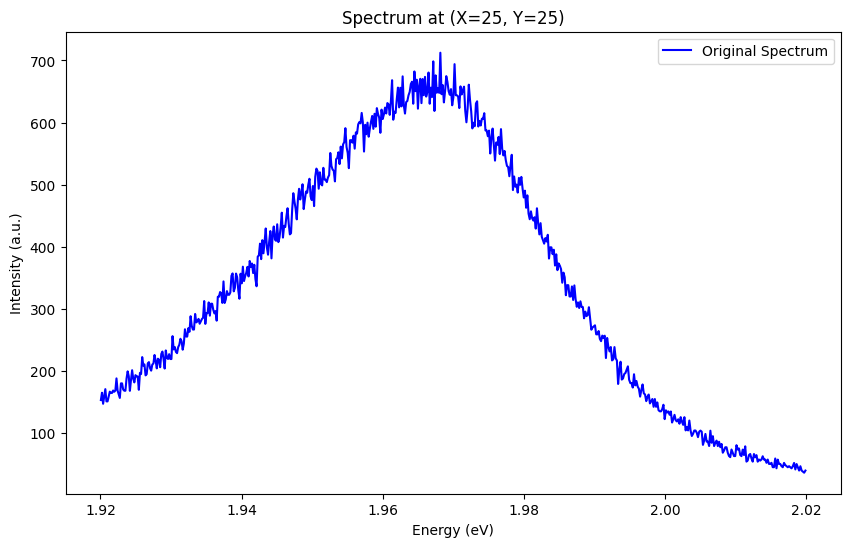

In [5]:
from ramanpl import Mapping

filename = 'Mapping PL Sample' + '.wdf'
step_size = 1.7  # in microns

# Initialise PL_Integration class
pl_integration = Mapping.PL_Integration(filename, integration_range=(1.92, 2.02), step_size=step_size, 
                                        # poly_degree=3, 
                                        background_remove=False
                                        )

# Show optical image
pl_integration.show_optical_image()

# Calculate the integration
pl_integration.calculate_integration()

# Plot the integration heatmap
pl_integration.plot_integration_heatmap()

# Plot spectrum at a specific data point
pl_integration.plot_spectrum(x=25, y=25)

### Export integration map to file
You can export the integrated intensity maps to text or CSV files using the `export_integration_map` method. By default, the exported TXT file includes a metadata header. You can suppress this header by setting the `headers` parameter to `False`. The exported data files can be used elsewhere for further analysis or visualization.

```python

pl_integration.export_integration_map("outputs/pl_integration_map.txt", coord_mode="real")

```

In [6]:
pl_integration.calculate_integration()
pl_integration.export_integration_map("outputs/pl_WS2_integration_map.txt", coord_mode="real")

'outputs/pl_WS2_integration_map.txt'

### PL integration from pre-processed data

Now you can also pass the intermediate metadata to integration or plotting functions as needed.

```python
from ramanpl import Mapping

pl_int = Mapping.PL_Integration.from_arrays(
    spectra=cubeC,
    xdata=xC,
    X=X,
    Y=Y,
    integration_range=(1.88, 2.05),
    step_size=1.7,
    background_remove=False,
    baseline_method="poly",
)

pl_int.integrate()
pl_int.plot_integration_map()
```

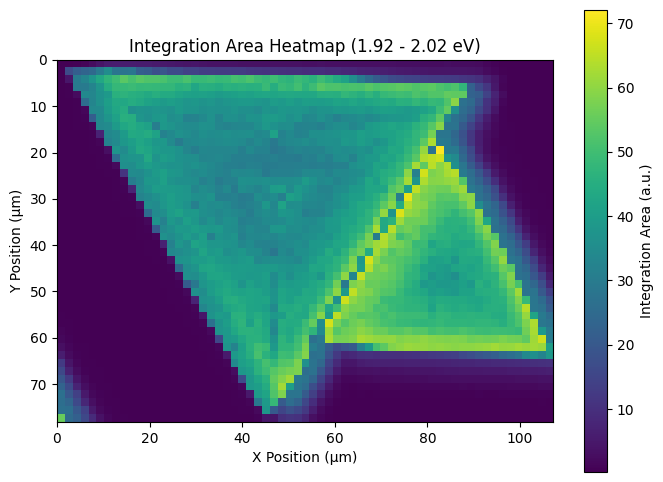

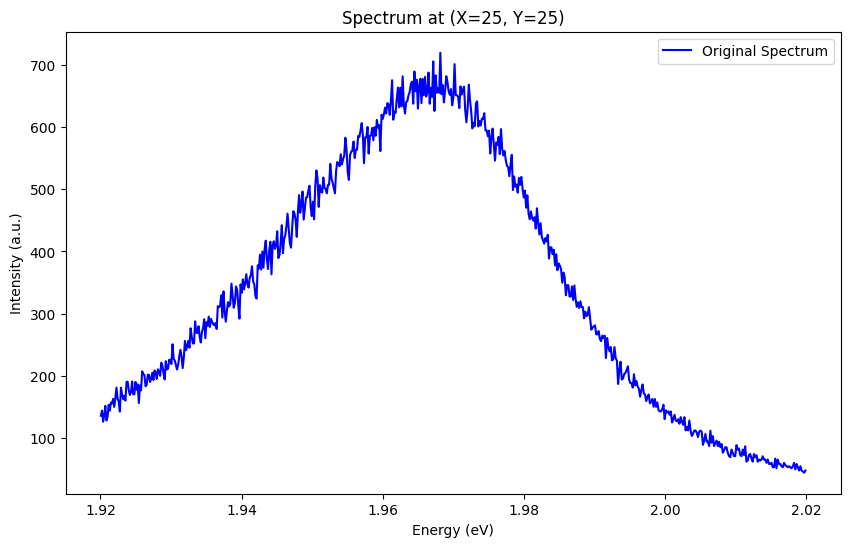

In [7]:
from ramanpl import Mapping
from ramanpl.operation import ArithmeticSpectrum

cubeC, xC, X, Y = ArithmeticSpectrum.combine_map_with_reference(
    "Mapping PL Sample.wdf",        # mapping data file
    "PL_Si_ref.txt",                # single reference spectrum
    op="sub",
    k=1,
    axis="energy",         # This tells the code the unit:'wavenumber' or 'energy'
    align="interp",
    save=True,                      # (optional) save the combined result
    out_path="PL_map_subtracted.txt",         # If save=True, output file name must be provided
)

pl_int = Mapping.PL_Integration.from_arrays(
    spectra=cubeC,
    xdata=xC,
    X=X,
    Y=Y,
    integration_range=(1.92, 2.02),
    step_size=1.7,
    background_remove=False,
    # baseline_method="poly",
)

pl_int.calculate_integration()
pl_int.plot_integration_heatmap()
pl_int.plot_spectrum(x=25, y=25)
